<a href="https://colab.research.google.com/github/sangeetha457/sangeetha/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
from google.colab import files
uploaded = files.upload()

Saving top-5000-youtube-channels.csv to top-5000-youtube-channels.csv


In [5]:
df = pd.read_csv('top-5000-youtube-channels.csv')
df.head()

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433


In [7]:
def convert_str_to_num(x):
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'K' in x:
            return float(x.replace('K', ''))* 1_000
        elif 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'B' in x:
            return float(x.replace('B', '')) * 1_000_000_000
    try:
        return float(x)
    except:
        return np.nan

In [15]:
df['Subscribers'] = df['Subscribers'].apply(convert_str_to_num)
df['Video views'] = df['Video views'].apply(convert_str_to_num)
df['Video Uploads'] = df['Video Uploads'].apply(convert_str_to_num)

In [16]:
df.dropna(subset=['Subscribers', 'Video views', 'Video Uploads'], inplace=True)

In [17]:
X = df[['Video views', 'Video Uploads']]
y = df['Subscribers']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R² Score: 0.5512101383896096
Mean Squared Error: 5746531680765.533


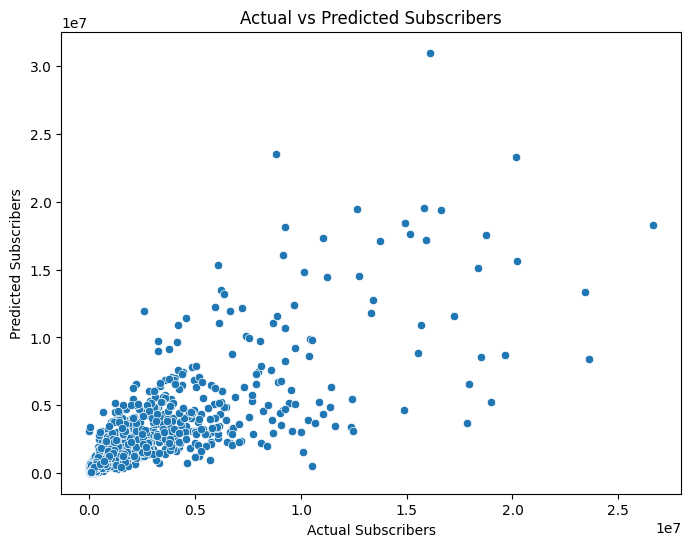

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Subscribers")
plt.ylabel("Predicted Subscribers")
plt.title("Actual vs Predicted Subscribers")
plt.show()